# EDA of the dataset

### Goal
Glance at the data saved, analyze missing values and distribution

In [50]:
# import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [51]:
# constants
REPO_ROOT = Path.cwd().parent
RAW_DIR = REPO_ROOT / "data" / "raw"

In [52]:
df = pd.read_csv(RAW_DIR / "Walmart.csv")

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [54]:
# typecasting
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [55]:
df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885


In [56]:
df.groupby('Store').count()

,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Store,,,,,,,
1,143,143,143,143,143,143,143
2,143,143,143,143,143,143,143
3,143,143,143,143,143,143,143
4,143,143,143,143,143,143,143
5,143,143,143,143,143,143,143
6,143,143,143,143,143,143,143
7,143,143,143,143,143,143,143
8,143,143,143,143,143,143,143
9,143,143,143,143,143,143,143


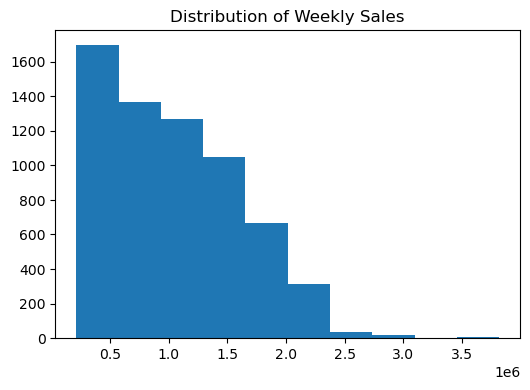

In [57]:
plt.figure(figsize=(6,4))
plt.hist(df['Weekly_Sales'])
plt.title('Distribution of Weekly Sales')
plt.show()

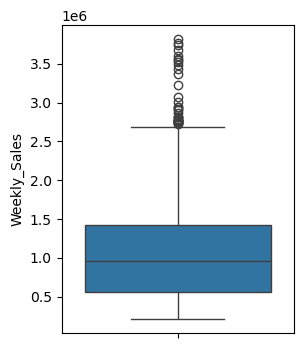

In [58]:
plt.figure(figsize=(3,4))
sns.boxplot(df['Weekly_Sales'])
plt.show()

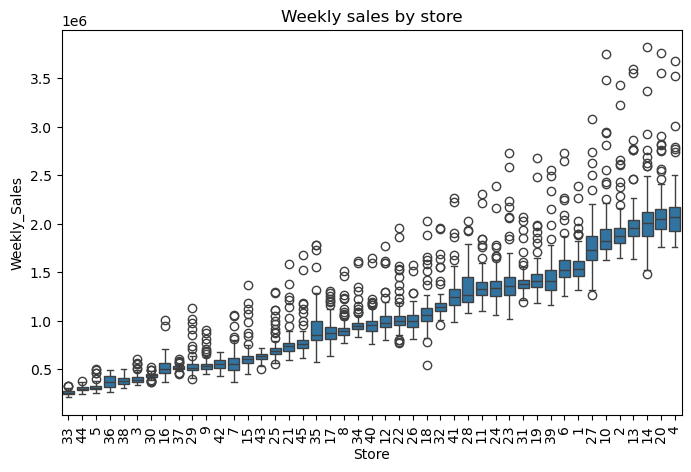

In [59]:
order = df.groupby('Store')['Weekly_Sales'].median().sort_values().index
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Store', y='Weekly_Sales', order=order)
plt.title('Weekly sales by store')
plt.xticks(rotation=90)
plt.show()

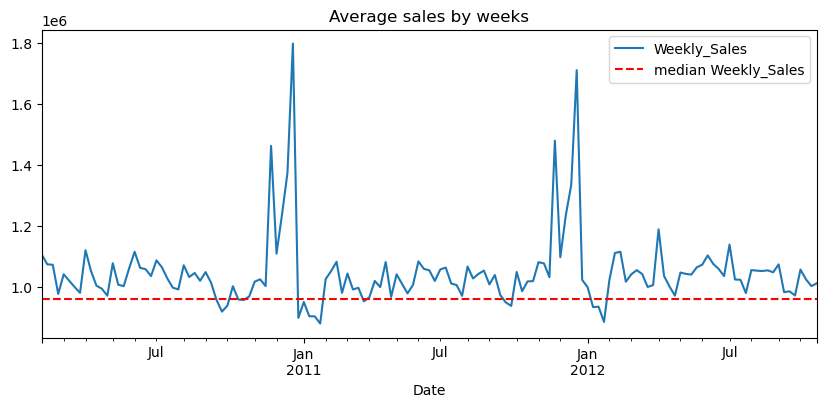

In [60]:
plt.figure(figsize=(10,4))
df.groupby('Date')['Weekly_Sales'].mean().plot()
plt.axhline(df['Weekly_Sales'].median(), color='r', linestyle='--', label='median Weekly_Sales')
plt.legend()
plt.title('Average sales by weeks')
plt.show()

Text(0.5, 1.0, 'Correlation matrix to identify relations with the target variable (Weekly_Sales)')

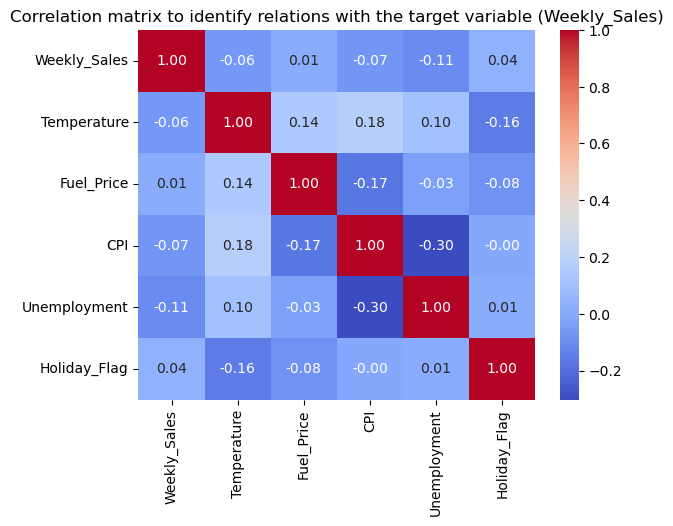

In [61]:
num = ['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment','Holiday_Flag']
sns.heatmap(df[num].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix to identify relations with the target variable (Weekly_Sales)')

In [62]:
grand = df['Weekly_Sales'].mean()
ss_tot = ((df['Weekly_Sales'] - grand) ** 2).sum() # total variance
ss_between = df.groupby('Store')['Weekly_Sales'].apply(
    lambda x: len(x) * (x.mean() - grand) ** 2).sum()          # variance by stores
eta_sq = ss_between / ss_tot

print(eta_sq)

0.9174153734732021


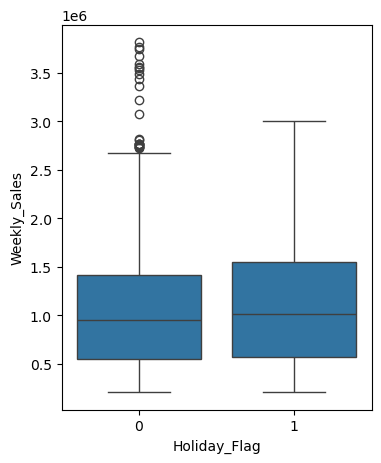

<Figure size 640x480 with 0 Axes>

In [63]:
plt.figure(figsize=(4,5))
sns.boxplot(data=df, x='Holiday_Flag', y='Weekly_Sales')
plt.figure('Do weekly sales differ on holidays?')
plt.show()

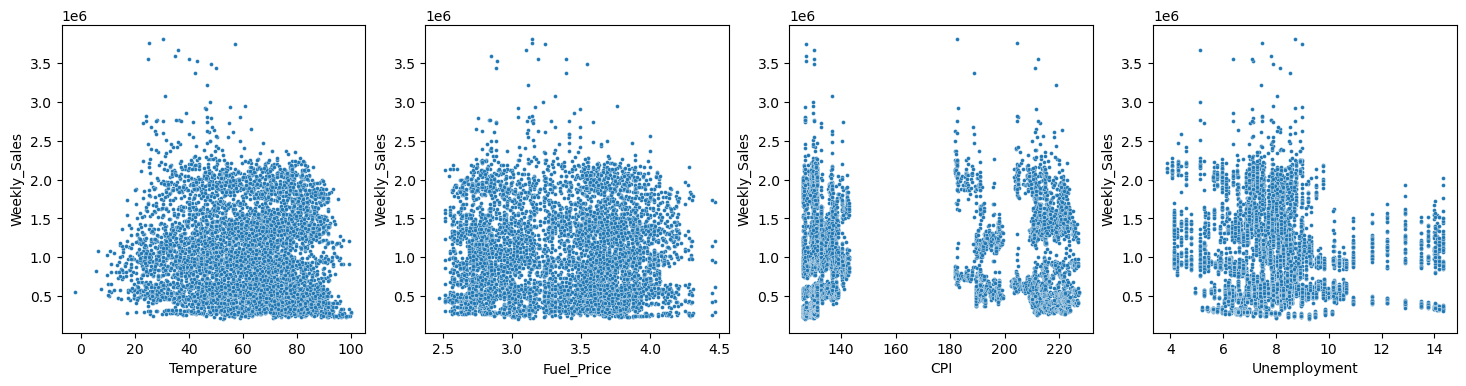

In [64]:
fig, ax = plt.subplots(1, 4, figsize=(18,4))
for a, col in zip(ax, ['Temperature','Fuel_Price','CPI','Unemployment']):
    sns.scatterplot(data=df, x=col, y='Weekly_Sales', s=8, ax=a)

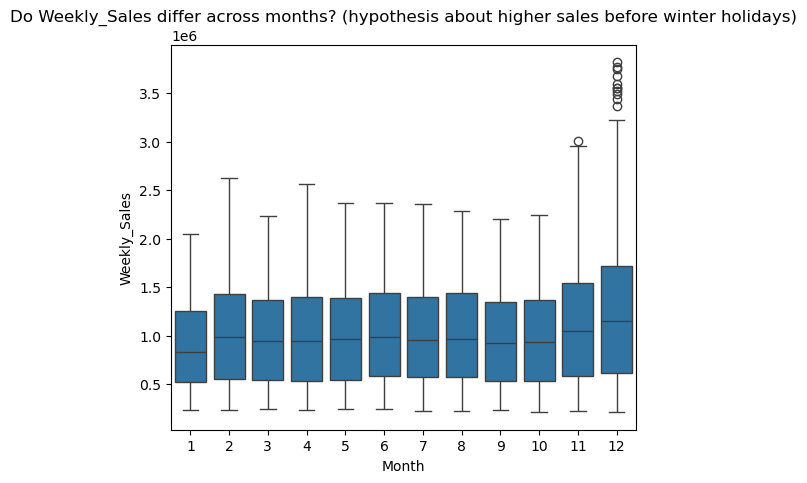

In [65]:
df['Month'] = df['Date'].dt.month
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='Month', y='Weekly_Sales')
plt.title('Do Weekly_Sales differ across months? (hypothesis about higher sales before winter holidays)')
plt.show()

## Conclusions

- Store is the main predictor: it explains almost 92% of the variance in Weekly_Sales (store size effect). It must be included as a feature.
- Macro features are weak linear predictors: abs(correlation) is at most 0.11 for Temperature, Fuel_Price, CPI, Unemployment. Relationships are non-linear/noisy and a tree-based model is preferable to linear regression.
- Average weekly sales are higher on holidays.
- Seasonality is present: sales peak in November–December (pre-holiday season).
- Data is clean: no missing values, only few rows are global IQR outliers, mostly legitimate large-store/holiday peaks, so outlier removal should be conservative.